# 05_streaming

对应 `index.md` 第 5 阶段：`stream(stream_mode="updates"/"values"/"messages")`、多模式、`astream`。

笔记本在 `codes/langgraph/05_streaming/qa.ipynb`。需要读写文件时，工作空间就是这个目录。

先运行下一格，得到 `ROOT` 并加载 `codes/langgraph/local.env`。每题只改 `# 作答` 下面的代码。前置代码不用改。做完自己跑通即可，先不要对答案。

前面四阶段都在用 `invoke`：图跑完才把最终 state 一次交给你。但聊天界面不能等整段回复——得一个字一个字往外吐。`app.stream(...)` 就是干这个的：它返回一个**迭代器**，图每推进一步（或每吐一个 token）就 yield 一块，`stream_mode` 决定这一块长什么样。

- `"updates"`：**增量**。一块只含刚跑完的那个节点写回的那点数据，key 是节点名。
- `"values"`：**全量**。一块就是当时的完整 state。
- `"messages"`：**逐 token**。一块是 `(AIMessageChunk, metadata)`，metadata 里带 `langgraph_node`。

`stream_mode` 还能传**列表**，同时吐多种；这时每块变成 `(mode, data)` 元组。`invoke` / `stream` 的异步双胞胎是 `ainvoke` / `astream`。第 1 题起都要调 API。


In [1]:
import os
from pathlib import Path

def lab_root() -> Path:
    """qa.ipynb 所在目录。"""
    here = Path.cwd().resolve()
    for folder in [here, *here.parents]:
        if folder.name == "05_streaming" and (folder / "qa.ipynb").is_file():
            return folder
        candidate = folder / "codes" / "langgraph" / "05_streaming"
        if (candidate / "qa.ipynb").is_file():
            return candidate
    return here

def load_local_env(env_path: Path) -> None:
    """把 local.env 写入 os.environ（已有键不覆盖）。"""
    if not env_path.is_file():
        return
    for raw in env_path.read_text(encoding="utf-8").splitlines():
        line = raw.strip()
        if not line or line.startswith("#") or "=" not in line:
            continue
        key, _, value = line.partition("=")
        key = key.strip()
        value = value.strip().strip("\"'")
        if key and key not in os.environ:
            os.environ[key] = value

ROOT = lab_root()
load_local_env(ROOT.parent / "local.env")
ROOT, bool(os.environ.get("DEEPSEEK_API_KEY"))


(PosixPath('/Users/keyficller/Documents/AEFS-Notes/codes/langgraph/05_streaming'),
 True)

## 1. `stream_mode="updates"`：一步一块，只给增量

已有 `model`、节点 `researcher` / `writer`、建好的 `graph`，以及 `app = graph.compile()`（`START → researcher → writer → END`）。

1. `for chunk in app.stream({"messages": [HumanMessage("开始")]}, stream_mode="updates"):`
2. 每块打印 `list(chunk.keys())`，以及该块里那个节点新写回的消息条数
3. 循环外打印一共拿到几块

预期两块：先是 `['researcher']`，再是 `['writer']`，各带 1 条新消息。注意每块**不是**完整 state，`list(chunk.values())[0]` 才是那个节点的部分更新。对比一下：`invoke` 只会给你最后那一份完整 state，中间过程看不到。


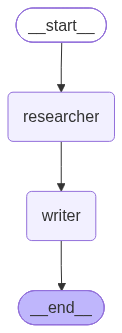

researcher 1 在标准大气压下，水的沸点是100摄氏度（212华氏度）。
writer 1 在标准大气压条件下，水的沸点为100摄氏度（即212华氏度）。
2


In [9]:
import os

from langchain.chat_models import init_chat_model
from langchain_core.messages import HumanMessage
from langgraph.graph import END, START, MessagesState, StateGraph

model = init_chat_model(
    f"deepseek:{os.environ.get('DEEPSEEK_MODEL', 'deepseek-v4-flash')}"
)

def researcher(state: MessagesState) -> dict:
    return {"messages": [model.invoke([HumanMessage("用一句话说：水的沸点是多少。")])]}

def writer(state: MessagesState) -> dict:
    return {"messages": [model.invoke(state["messages"] + [HumanMessage("把上面那句话改写得更正式。")])]}

graph = StateGraph(MessagesState)
graph.add_node("researcher", researcher)
graph.add_node("writer", writer)
graph.add_edge(START, "researcher")
graph.add_edge("researcher", "writer")
graph.add_edge("writer", END)

app = graph.compile()

# 作答

from IPython.display import display, Image
display(Image(app.get_graph().draw_mermaid_png()))

count = 0
for chunk in app.stream(
    {"messages": [HumanMessage("开始")]},
    stream_mode="updates"
):
    for node, msg in chunk.items():
        print(node, len(msg), msg["messages"][-1].content)
    count += 1

print(count)
#评阅
# 对。两块：researcher、writer 各 1 条新消息，count == 2。用 chunk.items() 同时拿节点名和部分更新，
# 等价于题面说的 list(chunk.keys()) + chunk[node]。
# 小点：`len(msg)` 数的是**部分更新字典的键数**（这里恰好只有 messages 一个键，所以是 1），
# 不是消息条数。要消息条数应写 len(msg["messages"])。这题两者数值碰巧一样，
# 哪天一个节点同时返回 messages 和别的字段，`len(msg)` 就会骗你。

#参考答案
# n = 0
# for chunk in app.stream({"messages": [HumanMessage("开始")]}, stream_mode="updates"):
#     n += 1
#     node = next(iter(chunk))
#     print(node, len(chunk[node]["messages"]))
# print("chunks:", n)        # researcher 1 / writer 1 / chunks: 2



## 2. `stream_mode="values"`：一步一块，给全量 state

同样的图，换成 `"values"`。这时每块就是**当时的完整 state**。

已有 `model`、`researcher` / `writer`、`graph`、`app`。

1. `for chunk in app.stream({"messages": [HumanMessage("开始")]}, stream_mode="values"):`
2. 打印 `len(chunk["messages"])`

预期打出 3 行：`1`、`2`、`3`。第一块是**你传进去的输入**（还没跑任何节点），之后每跑完一个节点多一条消息。

和上一题的选择标准：要「谁在什么时候干了什么」用 `updates`；要「此刻 state 长什么样」用 `values`。


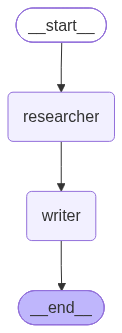

1
开始
--------------------------------------------------
2
开始
在标准大气压（1个大气压）下，水的沸点是100摄氏度（212华氏度，373.15开尔文）。
--------------------------------------------------
3
开始
在标准大气压（1个大气压）下，水的沸点是100摄氏度（212华氏度，373.15开尔文）。
在标准大气压条件下，水的沸点为100摄氏度，即212华氏度或373.15开尔文。
--------------------------------------------------


In [12]:
import os

from langchain.chat_models import init_chat_model
from langchain_core.messages import HumanMessage
from langgraph.graph import END, START, MessagesState, StateGraph

model = init_chat_model(
    f"deepseek:{os.environ.get('DEEPSEEK_MODEL', 'deepseek-v4-flash')}"
)

def researcher(state: MessagesState) -> dict:
    return {"messages": [model.invoke([HumanMessage("用一句话说：水的沸点是多少。")])]}

def writer(state: MessagesState) -> dict:
    return {"messages": [model.invoke(state["messages"] + [HumanMessage("把上面那句话改写得更正式。")])]}

graph = StateGraph(MessagesState)
graph.add_node("researcher", researcher)
graph.add_node("writer", writer)
graph.add_edge(START, "researcher")
graph.add_edge("researcher", "writer")
graph.add_edge("writer", END)

app = graph.compile()

# 作答

from IPython.display import display, Image
display(Image(app.get_graph().draw_mermaid_png()))

for chunk in app.stream(
    {"messages": [HumanMessage("开始")]},
    stream_mode="values"
):
    print(len(chunk["messages"]))
    for msg in chunk["messages"]:
        print(msg.content)
    print("-----"*10)
#评阅
# 对。1 → 2 → 3，第一块就是传进去的输入（还没跑节点）。你没停在 len，还把每块里的消息全打出来，
# 正好看见 values 是**累积**的全量 state——这一步加得好。
# 顺带记一笔：历史越长，values 每块携带的消息越多，比 updates 重；要「谁干了什么」用 updates，
# 要「此刻 state 长什么样」才用 values。

#参考答案
# for chunk in app.stream({"messages": [HumanMessage("开始")]}, stream_mode="values"):
#     print(len(chunk["messages"]))        # 1 / 2 / 3




## 3. `stream_mode="messages"`：逐 token 流

`"messages"` 不按节点分块，而是把节点里模型生成的 token **一个个**吐出来。每块是 `(chunk, metadata)` 二元组，`chunk` 是 `AIMessageChunk`（`.content` 就是一两个字的片段），`metadata["langgraph_node"]` 告诉你这个 token 出自哪个节点。

已有 `model`、`researcher` / `writer`、`graph`、`app`。

1. 准备一个空字典 `buffers = {}`
2. `for chunk, meta in app.stream({"messages": [HumanMessage("开始")]}, stream_mode="messages"):`
3. 只处理 `chunk.content` 非空的块：把内容按 `meta["langgraph_node"]` 累加进 `buffers`
4. 循环后遍历 `buffers`，打印节点名、拼接后文本的**长度**和文本本身

两个坑：流里混着不少 `content == ""` 的空块（工具调用 / 用量信息），不跳过也不影响拼接；两块内容会明显长于最终回复的字数——因为 `researcher` 的整段回答也经过了流。想只截取真正「说给人看」的那段，就得自己按节点挑。


In [14]:
import os

from langchain.chat_models import init_chat_model
from langchain_core.messages import HumanMessage
from langgraph.graph import END, START, MessagesState, StateGraph

model = init_chat_model(
    f"deepseek:{os.environ.get('DEEPSEEK_MODEL', 'deepseek-v4-flash')}"
)

def researcher(state: MessagesState) -> dict:
    return {"messages": [model.invoke([HumanMessage("用一句话说：水的沸点是多少。")])]}

def writer(state: MessagesState) -> dict:
    return {"messages": [model.invoke(state["messages"] + [HumanMessage("把上面那句话改写得更正式。")])]}

graph = StateGraph(MessagesState)
graph.add_node("researcher", researcher)
graph.add_node("writer", writer)
graph.add_edge(START, "researcher")
graph.add_edge("researcher", "writer")
graph.add_edge("writer", END)

app = graph.compile()

# 作答

buffers = {}

for chunk, meta in app.stream(
    {"messages": [HumanMessage("开始")]},
    stream_mode= "messages"
):
    if chunk.content:
        buffers[meta["langgraph_node"]] = buffers.get(meta["langgraph_node"], "") + chunk.content
        print(f"Token: {chunk.content}")

for node, text in buffers.items():
    print(node, len(text), text)
#评阅
# 对。两条 buffer 分别 20 / 22 字，拼接完整；`if chunk.content` 把空块滤掉也是对的。
# 逐 token 打印是这题最直观的产物，说明你确实看到「流」了。提醒一句：长回答下每 token 一行会刷屏，
# 真实 UI 里通常是原地增量 append 到同一块文本区，而不是每 token 打一行。
# 小点：`stream_mode= "messages"` 等号后多一个空格；关键字参数按 PEP8 不写空格。

#参考答案
# buffers = {}
# for chunk, meta in app.stream({"messages": [HumanMessage("开始")]}, stream_mode="messages"):
#     if chunk.content:
#         node = meta["langgraph_node"]
#         buffers[node] = buffers.get(node, "") + chunk.content
# for node, text in buffers.items():
#     print(node, len(text), text)



Token: 在
Token: 标准
Token: 大气
Token: 压下
Token: ，
Token: 水的
Token: 沸
Token: 点是
Token: 100
Token: 摄氏度
Token: 。
Token: 在
Token: 标准
Token: 大气
Token: 压
Token: 条件下
Token: ，
Token: 水的
Token: 沸
Token: 点为
Token: 100
Token: 摄氏度
Token: 。
researcher 20 在标准大气压下，水的沸点是100摄氏度。
writer 22 在标准大气压条件下，水的沸点为100摄氏度。


## 4. 多模式：`stream_mode=["updates", "messages"]`

一次跑，两路数据同时吐。传列表时每块变成 `(mode, data)` 元组：`mode` 是字符串（`"updates"` 或 `"messages"`），`data` 是对应模式原本的那块。

已有 `model`、`researcher` / `writer`、`graph`、`app`。

1. `for mode, data in app.stream({"messages": [HumanMessage("开始")]}, stream_mode=["updates", "messages"]):`
2. 用一个 `dict` 统计每种 `mode` 各出现多少次
3. 当 `mode == "updates"` 时，把 `list(data.keys())` 记进一个列表
4. 循环后打印统计结果，以及 `updates` 收集到的节点名顺序

预期：`updates` 恰好 2 块，节点名顺序是 `researcher` 然后 `writer`；`messages` 是几十上百块。`data` 在 `messages` 模式下仍是 `(chunk, metadata)`，取用前先拆包。


In [18]:
import os

from langchain.chat_models import init_chat_model
from langchain_core.messages import HumanMessage
from langgraph.graph import END, START, MessagesState, StateGraph

model = init_chat_model(
    f"deepseek:{os.environ.get('DEEPSEEK_MODEL', 'deepseek-v4-flash')}"
)

def researcher(state: MessagesState) -> dict:
    return {"messages": [model.invoke([HumanMessage("用一句话说：水的沸点是多少。")])]}

def writer(state: MessagesState) -> dict:
    return {"messages": [model.invoke(state["messages"] + [HumanMessage("把上面那句话改写得更正式。")])]}

graph = StateGraph(MessagesState)
graph.add_node("researcher", researcher)
graph.add_node("writer", writer)
graph.add_edge(START, "researcher")
graph.add_edge("researcher", "writer")
graph.add_edge("writer", END)

app = graph.compile()

# 作答

count = {}
update_ls = []

for mode, data in app.stream(
    {"messages": [HumanMessage("开始")]},
    stream_mode=["updates", "messages"]
):
    count[mode] = count.get(mode, 0) + 1
    if mode == "updates":
        update_ls.extend(list(data.keys()))

print(count)
print(update_ls)
#评阅
# 对。`{'messages': 524, 'updates': 2}`，节点顺序 researcher → writer，update_ls 收的正是节点名列表。
# 用 extend 而不是 append 也对——你要的就是「所有块里的节点名摊平成一条列表」。
# 一点补充：messages 模式下的 data 你这次没拆包（也没用到），没问题；真要用得先 `chunk, meta = data`，
# 它和单模式时一样是 (AIMessageChunk, metadata)。

#参考答案
# counts, node_order = {}, []
# for mode, data in app.stream({"messages": [HumanMessage("开始")]}, stream_mode=["updates", "messages"]):
#     counts[mode] = counts.get(mode, 0) + 1
#     if mode == "updates":
#         node_order.extend(data.keys())
# print(counts, node_order)     # {'messages': ..., 'updates': 2} ['researcher', 'writer']



{'messages': 524, 'updates': 2}
['researcher', 'writer']


## 5. `astream`：异步版 `stream`

`astream` 和 `stream` 是同一套 `stream_mode`，只是返回**异步迭代器**，要用 `async for`。

**笔记本里直接写顶层 `await` / `async for`**——`ipykernel` 已经在跑事件循环，再调 `asyncio.run(main())` 会报 `RuntimeError: asyncio.run() cannot be called from a running event loop`。在 `.py` 脚本里才需要 `async def main()` 再 `asyncio.run(main())`。

已有 `model`、`researcher` / `writer`、`graph`、`app`。

1. `async for chunk in app.astream({"messages": [HumanMessage("开始")]}, stream_mode="values"):`，打印 `len(chunk["messages"])`（应打出 `1`、`2`、`3`）
2. 再开一轮 `async for chunk, meta in app.astream({"messages": [HumanMessage("开始")]}, stream_mode="messages"):`，把非空的 `chunk.content` 拼成一个字符串
3. 打印那个字符串的长度，以及它是否以任意空白结尾之外还包含中文（比如 `len(text)`, `text[:20]`）

图里的节点是同步 `def`，`astream` 照样能流——LangGraph 会把同步节点丢到线程里跑。所以接 Web 框架时，同步图也能直接进 `async` 路由。


In [ ]:
import os

from langchain.chat_models import init_chat_model
from langchain_core.messages import HumanMessage
from langgraph.graph import END, START, MessagesState, StateGraph

model = init_chat_model(
    f"deepseek:{os.environ.get('DEEPSEEK_MODEL', 'deepseek-v4-flash')}"
)

def researcher(state: MessagesState) -> dict:
    return {"messages": [model.invoke([HumanMessage("用一句话说：水的沸点是多少。")])]}

def writer(state: MessagesState) -> dict:
    return {"messages": [model.invoke(state["messages"] + [HumanMessage("把上面那句话改写得更正式。")])]}

graph = StateGraph(MessagesState)
graph.add_node("researcher", researcher)
graph.add_node("writer", writer)
graph.add_edge(START, "researcher")
graph.add_edge("researcher", "writer")
graph.add_edge("writer", END)

app = graph.compile()

# 作答

async for chunk in app.astream({"messages": [HumanMessage("开始")]}, stream_mode="values"):
    print(len(chunk["messages"]))

text = ""
async for chunk, meta in app.astream({"messages": [HumanMessage("开始")]}, stream_mode="messages"):
    if chunk.content:
        text += chunk.content

print(len(text), text[:20], text.endswith("。"))
#评阅
# 对。顶层 `async for` 直接跑通（values 打出 1 / 2 / 3），第二轮把非空 token 拼成 90 字、
# 且以「。」收尾——说明拼接是完整可读的中文，不是半截。
# 题面第 3 步「是否…还包含中文」那句我写得含糊，你换成 `text.endswith("。")` 是个更干脆的判据，好。
# 记住 90 字 > 最后一条回复的字数：researcher 那一整段也过了流，想只取「给人看」的那段得按节点挑
# （或直接看最后一条 AI 消息，它正好是 text 的尾部）。

#参考答案
# async for chunk in app.astream({"messages": [HumanMessage("开始")]}, stream_mode="values"):
#     print(len(chunk["messages"]))        # 1 / 2 / 3
#
# text = ""
# async for chunk, meta in app.astream({"messages": [HumanMessage("开始")]}, stream_mode="messages"):
#     if chunk.content:
#         text += chunk.content
# print(len(text), text[:20], text.endswith("。"))




1
2
3
93 在标准大气压（1 atm）下，水的沸点是100摄氏度（212华氏度或373.15开尔文）。在标准大气压（1 atm）条件下，水的沸点为100摄氏度（即212华氏度或373.15开尔文）。 True
